# Project 1 — Who Scores More Than Expected?

## The mystery we're solving

Imagine two NBA players. Player A takes **25 shots** a game and scores **28 points**. Player B takes **10 shots** and scores **18 points**.

Who's the better scorer?

Most people would say *"Player A — 28 is more than 18!"*. But hold on. **Player A used way more chances** to get those 28 points. If you gave Player B 25 shots, would they score 50?

That's the question this whole project answers — using machine learning to figure out **how many points each player *should have* scored, based on how many shots they took**, and then asking: *who consistently scored MORE than that?* Those players are the **truly efficient scorers**.

## What we'll do, in plain English

1. Train a small ML model that takes someone's shots-per-game as input and predicts their points.
2. For every real game, see how the player did vs. what the model expected — that gap is called a **residual**.
3. Average each player's residuals across the season → that's their **"points above expected"** score.
4. Make a leaderboard. Anyone surprised by who's at the top?

## What you'll learn

- How an ML model can be used as a **measurement tool**, not just a fortune-teller.
- What a **residual** is, and why analytics teams care about them.
- How to use **groupby** to summarise thousands of rows into a leaderboard.
- How to read a scatter plot of **volume vs efficiency** — the way pro basketball analysts think about scoring.

> **Heads-up:** this notebook builds directly on [Project 0 (EDA)](00_eda.ipynb). If you haven't done that one, the data quirks (especially the leakage warning about `FG`/`3P`/`FT`) won't make sense.


## 1. Setup

We need three Python libraries:
- **pandas** — for handling the data table.
- **scikit-learn** — for the ML model and evaluation tools.
- **matplotlib / seaborn** — for the charts.

The line `RANDOM_STATE = 42` is a **seed** for the random number generator. Every time the notebook runs, the model uses the same "random" choices, so you and a classmate will get the **exact same results**. The number `42` is just a famous joke — any integer works.


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model     import LinearRegression
from sklearn.tree             import DecisionTreeRegressor
from sklearn.ensemble         import RandomForestRegressor
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 2. Load the data

Same dataset as the EDA notebook — one row per player per game. From EDA we already know:
- 16,512 rows, no missing values.
- 562 unique players, 30 teams, ~50 games per team.
- The `Data` column is actually the date (yes, it's a typo in the source CSV).


In [69]:
DATA_PATH = "../data/nbadatabase_24_25 2/nbadatabase_24_25.csv"
df = pd.read_csv(DATA_PATH)
print("Rows:", len(df))
df.head()

Rows: 16512


,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,...,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,...,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,...,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,...,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,...,0,0,2,0,0,1,1,22,17.8,2024-10-22


## 3. The plan: build an "expected points" model

> **What this section does, in one sentence:**
> Train a small ML model that takes **4 inputs** about a player's game — minutes played (`MP`), shot attempts (`FGA`), three-point attempts (`3PA`), free-throw attempts (`FTA`) — and predicts **1 output**: the points (`PTS`) the player would score *if they were a league-average shooter*. We then compare the model's prediction to what actually happened. The gap is each player's "edge" over (or below) the league.

```
INPUTS (4 features)                             OUTPUT (1 prediction)
  MP   minutes played                              expected_PTS
  FGA  field-goal attempts          ----------->   (what an average
  3PA  three-point attempts                        player would score
  FTA  free-throw attempts                         given those inputs)
```

### The big idea

We're going to teach a small ML model **one thing**: *given how many shots a player took (and minutes they played), how many points does the average NBA player score?*

That model becomes our **measuring stick**. For every real game, we compare what actually happened to what the measuring stick predicted. The gap is the **residual** — that's the player's edge over (or below) the league average.

### Picking features without cheating

We'll use these as **features** (inputs):
- `MP` — minutes played
- `FGA` — field-goal attempts
- `3PA` — three-point attempts
- `FTA` — free-throw attempts

And **`PTS`** is the target (what we're predicting).

> **Why we don't use `FG`, `3P`, or `FT`:** EDA Section 8 showed `FG ↔ PTS` correlates at **+0.97** — almost perfect. That's because the points are *literally* computed from those numbers (`PTS = 2·(FG−3P) + 3·3P + FT`). If we let the model see them, it would just memorise the formula. That's called **target leakage**, and it makes a model look smart without actually doing anything.

### Trying THREE simple models and comparing

Instead of jumping straight to one fancy model, we'll **try three simple ones** and see how they compare. This is good practice — you should always have a simple baseline before believing in a complex one.

| Model | Plain-English description |
|---|---|
| **Linear Regression** | Finds the best straight-line formula: `predicted_PTS = a·MP + b·FGA + c·3PA + d·FTA + intercept`. The simplest possible model. |
| **Decision Tree** | A flowchart of yes/no questions on the features. Like *"if FGA > 12, predict 18; otherwise predict 8"*. We cap depth at 4 so it stays readable. |
| **Random Forest** | A whole *forest* of decision trees. Each tree sees a different random slice of the data; the final prediction is the average. More powerful than one tree but harder to interpret. |

### Vocab box — terms you'll see in the next cell

| Term | Plain-English meaning |
|---|---|
| **Regression** | An ML problem where you predict a *number* (here, points scored), not a category. |
| **Train / test split** | Cut the data in two. Train each model on 80% (the **training set**), test it on the unseen 20% (the **test set**). This is how we check the model didn't just memorise. |
| **MAE** (Mean Absolute Error) | On average, how many points off was the prediction? Lower is better. *MAE of 3 means the model's prediction was about 3 points away from the real number on average.* |
| **R²** (R-squared) | Between 0 and 1. Roughly: what fraction of the variation in points the model "explains". 1.0 = perfect, 0 = no better than guessing the average.

In [70]:
features = ["MP", "FGA", "3PA", "FTA"]
target   = "PTS"

X = df[features].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

candidates = {
    "Linear Regression":         LinearRegression(),
    "Decision Tree (depth 4)":   DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest (50 trees)":  RandomForestRegressor(
        n_estimators=50, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1),
}

results, trained = [], {}
for name, m in candidates.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    results.append({
        "Model": name,
        "MAE":   mean_absolute_error(y_test, pred),
        "R²":    r2_score(y_test, pred),
    })
    trained[name] = m

results_df = pd.DataFrame(results).round(3)
print(results_df.to_string(index=False))

                   Model   MAE    R²
       Linear Regression 2.579 0.846
 Decision Tree (depth 4) 2.857 0.814
Random Forest (50 trees) 2.567 0.843


### What just happened?

We trained three different models on the same 80% of the data and tested them on the unseen 20%. The numbers above tell us how each one did.

Typical results:
- **Linear Regression** — MAE around **2.6 points**, R² around **0.85**
- **Decision Tree** — MAE around **2.9 points**, R² around **0.81**
- **Random Forest** — MAE around **2.6 points**, R² around **0.84**

Notice something? The simple **Linear Regression is just as good as the fancy Random Forest** here. That's a really common finding in real data science: when the relationship between features and target is mostly straight-line (more shots → more points), a simple model is often plenty.

> **Decision:** we'll use **Linear Regression** for the rest of the notebook. It's the simplest, the most interpretable, and basically tied for best on accuracy.

### What did Linear Regression actually learn?

Because Linear Regression is so simple, we can read its "recipe" directly. Every feature gets a number (a **coefficient**) telling us how much that feature contributes to the prediction.

### Side-by-side: how do the three models compare visually?

The numbers in the comparison table told us all three models perform similarly. Let's confirm that visually. Each panel below shows one model's predictions vs the actual points scored on the same 3,303 test games. The red dashed line is "perfect prediction" - dots on it mean the model nailed it.

Look at the **shape** of each cloud: tighter along the line = more accurate. And watch for any weird patterns - the Decision Tree will look noticeably different from the other two.

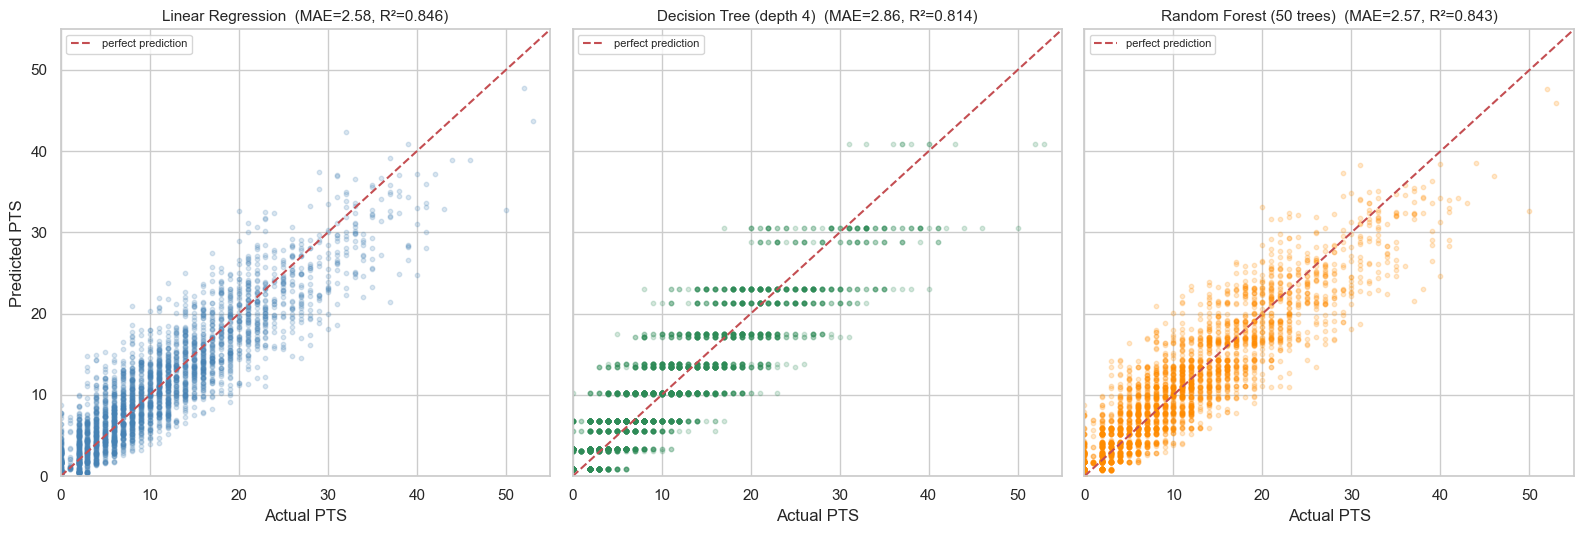

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True, sharex=True)

model_order = ["Linear Regression", "Decision Tree (depth 4)", "Random Forest (50 trees)"]
colors      = ["steelblue", "seagreen", "darkorange"]

for ax, name, color in zip(axes, model_order, colors):
    m = trained[name]
    pred = m.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2  = r2_score(y_test, pred)

    ax.scatter(y_test, pred, alpha=0.2, s=10, color=color)
    lims = [0, max(y_test.max(), pred.max()) + 2]
    ax.plot(lims, lims, "r--", lw=1.5, label="perfect prediction")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual PTS")
    ax.set_title(f"{name}  (MAE={mae:.2f}, R²={r2:.3f})", fontsize=11)
    ax.legend(loc="upper left", fontsize=8)

axes[0].set_ylabel("Predicted PTS")
plt.tight_layout(); plt.show()

### What to notice in the three panels

- **Linear Regression (left)** and **Random Forest (right)** look almost identical. Both produce smooth, tight clouds along the diagonal. Their accuracy numbers (MAE around 2.6, R² around 0.85) confirm what the eye sees.

- **Decision Tree (middle)** has a visibly different shape - the predictions form **horizontal stripes**. That's because a Decision Tree with depth 4 can only output 16 different prediction values (one per leaf). It doesn't matter how varied the inputs are; the prediction always lands on one of those 16 levels. That's why its MAE is slightly worse - it's stuck giving "rounded" answers.

- **The diagonal line is denser at low PTS** (0-15 points) for all three models. That makes sense: most player-games are low-scoring, so the model has lots of practice on those. Superstar 40+ point games are rare, so all three models are less precise out there.

> **What we just learned visually:** Linear Regression and Random Forest are basically tied; Decision Tree is held back by its limited number of outputs. The decision to use Linear Regression (simpler + interpretable + tied for best) is now visually justified, not just numerically.

In [72]:
lr = trained["Linear Regression"]

print("Linear Regression learned this formula:")
print(f"  predicted_PTS = {lr.intercept_:+.2f}", end="")
for feat, coef in zip(features, lr.coef_):
    print(f"  {coef:+.3f}*{feat}", end="")
print()
print()
print("In plain English:")
print(f"  - Each minute played adds {lr.coef_[0]:+.2f} points (tiny, since shots already capture most of it)")
print(f"  - Each field-goal attempt adds {lr.coef_[1]:+.2f} points  (close to 1 -- shots usually score about 1 point on average)")
print(f"  - Each three-point attempt adds an EXTRA {lr.coef_[2]:+.2f} points  (the bonus for being a 3-pointer)")
print(f"  - Each free-throw attempt adds {lr.coef_[3]:+.2f} points  (close to 0.78, the league free-throw %)")

Linear Regression learned this formula:
  predicted_PTS = -0.73  +0.038*MP  +1.021*FGA  +0.096*3PA  +0.804*FTA

In plain English:
  - Each minute played adds +0.04 points (tiny, since shots already capture most of it)
  - Each field-goal attempt adds +1.02 points  (close to 1 -- shots usually score about 1 point on average)
  - Each three-point attempt adds an EXTRA +0.10 points  (the bonus for being a 3-pointer)
  - Each free-throw attempt adds +0.80 points  (close to 0.78, the league free-throw %)


The coefficients **tell a real basketball story** that the model figured out by itself, just from the data:

- **`FGA` coefficient ≈ 1.0**: every shot you take adds about one point on average — because the league shoots around 46% on field goals, and most field goals are worth 2 points (so 0.46 × 2 ≈ 0.92, plus a bit from threes ≈ 1.0).
- **`FTA` coefficient ≈ 0.8**: every free-throw attempt adds about 0.8 points — because the league hits ~78% of free throws (worth 1 point each).
- **`3PA` coefficient ≈ 0.1**: a small *extra* bonus on top of the FGA contribution, because three-pointers are worth 3 instead of 2.

The model **rediscovered the basketball scoring rules from the data** — without us telling it. That's a great example of what supervised regression can learn.

### Visual check: predicted vs actual

How well does the model's prediction line up with reality? On the test set (games the model never saw during training), each dot below is one player-game. The red dashed line is "perfect prediction" — dots on it mean the model nailed it.


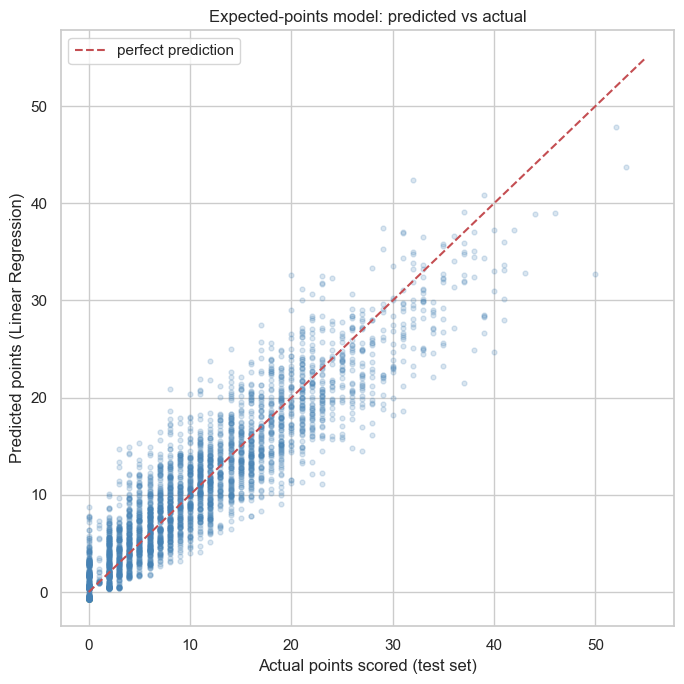

In [73]:
y_pred_test = lr.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred_test, alpha=0.2, s=12, color="steelblue")
lims = [0, max(y_test.max(), y_pred_test.max()) + 2]
ax.plot(lims, lims, "r--", lw=1.5, label="perfect prediction")
ax.set_xlabel("Actual points scored (test set)")
ax.set_ylabel("Predicted points (Linear Regression)")
ax.set_title("Expected-points model: predicted vs actual")
ax.legend()
plt.tight_layout(); plt.show()

## 4. Compute residuals — measure each game's surprise

Now we use the trained model on **every game** (all 16,512 rows) and compute:

> **`residual` = actual points scored − points the model expected**

A **positive** residual means the player overperformed that night. A **negative** one means they took a lot of shots without converting.

> **Reminder:** the model we're using is `lr` (Linear Regression). It takes 4 inputs (`MP`, `FGA`, `3PA`, `FTA`) and predicts `PTS`. Every game in `df` will get an `expected_PTS` from this model, then we compute the residual.


In [74]:
df["expected_PTS"] = lr.predict(df[features])
df["residual"]     = df["PTS"] - df["expected_PTS"]

df[["Player", "Tm", "Opp", "Data", "MP", "FGA", "PTS", "expected_PTS", "residual"]].head()

,Player,Tm,Opp,Data,MP,FGA,PTS,expected_PTS,residual
0,Jayson Tatum,BOS,NYK,2024-10-22,30.30,18,37,21.460246,15.539754
1,Anthony Davis,LAL,MIN,2024-10-22,37.58,23,36,36.534772,-0.534772
2,Derrick White,BOS,NYK,2024-10-22,26.63,13,24,16.119667,7.880333
3,Jrue Holiday,BOS,NYK,2024-10-22,30.52,9,18,10.189955,7.810045
4,Miles McBride,NYK,BOS,2024-10-22,25.85,10,22,13.352643,8.647357


### Reading the residual table

Look at row 0 — **Jayson Tatum**. He took 18 shots in 30 minutes against NYK and **scored 37 points**. Linear Regression's formula expected him to score about **21.5** based on that shot diet (mostly: 18 shots × ~1 point + 2 free-throw attempts × ~0.8). So his residual is roughly **+15.5** — a huge over-performance that night.

Compare to row 1 — **Anthony Davis** took **23 shots** in 37.6 minutes and scored 36. The model expected ~36.5 (a high number because his volume was huge). Residual: roughly **−0.5**. He scored about exactly what the formula predicts for that volume — efficient enough, but no special "edge" tonight.

> **What we just learned:** every player-game now has a "surprise score" — how much they beat (or missed) the league baseline.

### Visual check: how spread out are the surprises?

Now that every game has a residual, let's look at the whole distribution. We want to see two things:
1. The average residual should be near zero (otherwise the model is biased - it would systematically over- or under-predict).
2. There should be a real spread of residuals (otherwise there's no signal - everyone scores exactly what's expected).


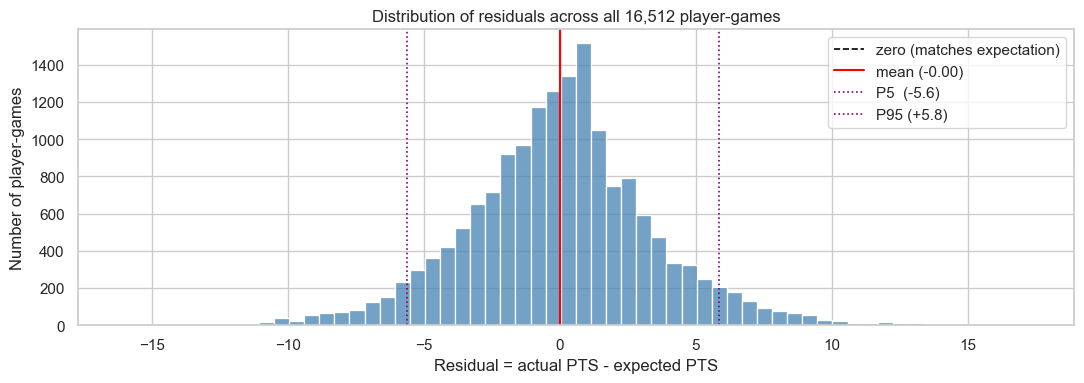

Mean residual:   -0.000  (should be near zero - it is)
Median residual: +0.072
5th-95th range:  -5.6  to  +5.8  points


In [75]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(df["residual"], bins=60, ax=ax, color="steelblue")

mean_r   = df["residual"].mean()
median_r = df["residual"].median()
p5, p95  = df["residual"].quantile([0.05, 0.95])

ax.axvline(0,        color="black",  linestyle="--", lw=1.2, label="zero (matches expectation)")
ax.axvline(mean_r,   color="red",    linestyle="-",  lw=1.5, label=f"mean ({mean_r:+.2f})")
ax.axvline(p5,       color="purple", linestyle=":",  lw=1.2, label=f"P5  ({p5:+.1f})")
ax.axvline(p95,      color="purple", linestyle=":",  lw=1.2, label=f"P95 ({p95:+.1f})")

ax.set_xlabel("Residual = actual PTS - expected PTS")
ax.set_ylabel("Number of player-games")
ax.set_title("Distribution of residuals across all 16,512 player-games")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Mean residual:   {mean_r:+.3f}  (should be near zero - it is)")
print(f"Median residual: {median_r:+.3f}")
print(f"5th-95th range:  {p5:+.1f}  to  {p95:+.1f}  points")

The distribution is roughly symmetric and centered very close to zero - exactly what we want from a fair baseline. The model is unbiased.

The spread is also informative: 90% of player-games have a residual between roughly -5 and +6 points. That tells us the "edge" we're hunting is small per-game (a few points), which is why we need to *average across many games* to detect a stable signal. One game's +14 residual could be noise; an *average* of +3.5 across 46 games (Jokic) is real.


## 5. From single games to a player profile

A single game's residual is **noisy** — even a great scorer can have a bad night. To get a stable measure of who *consistently* beats expectations, we average each player's residuals across all their games.

We only keep players with **at least 20 games** (`MIN_GAMES = 20`) so the average isn't ruined by a small sample. (EDA Section 5 showed why — players with very few games have unreliable averages, and Footgun C.3 reminds us this filter isn't bulletproof either.)

### Vocab box — pandas tools you'll see

| Code | What it does |
|---|---|
| `df.groupby("Player")` | Splits the table into 562 mini-tables, one per player. |
| `.agg(games=("PTS","size"), avg_PTS=("PTS","mean"), …)` | For each mini-table, compute these summary numbers. `"size"` = count of rows, `"mean"` = average. |
| `.query("games >= @MIN_GAMES")` | Keep only rows where `games` is at least `MIN_GAMES`. The `@` tells pandas to use the variable from outside the query string. |
| `.sort_values("avg_residual", ascending=False)` | Sort biggest residual first so the most-efficient scorers appear at the top. |


In [76]:
MIN_GAMES = 20

per_player = (df.groupby("Player")
                .agg(games=("PTS", "size"),
                     avg_MP=("MP", "mean"),
                     avg_FGA=("FGA", "mean"),
                     avg_PTS=("PTS", "mean"),
                     avg_expected_PTS=("expected_PTS", "mean"),
                     avg_residual=("residual", "mean"))
                .query("games >= @MIN_GAMES")
                .sort_values("avg_residual", ascending=False))

print(f"Qualified players: {len(per_player)}")
per_player.head()

Qualified players: 383


,games,avg_MP,avg_FGA,avg_PTS,avg_expected_PTS,avg_residual
Player,,,,,,
Nikola Jokić,46,36.232174,19.717391,29.695652,26.191862,3.503790
Shai Gilgeous-Alexander,50,34.074400,21.500000,32.440000,29.937409,2.502591
Domantas Sabonis,48,35.985208,13.250000,20.395833,17.949175,2.446658
Jarrett Allen,52,28.927500,7.942308,13.615385,11.217749,2.397636
Daniel Gafford,49,22.023878,7.265306,12.612245,10.298200,2.314045


## 6. Leaderboards

Here's the payoff — the actual ranking of NBA scorers by **points above expected**, averaged across the 2024-25 season.

### Top 15 — players who consistently score more than expected


In [77]:
top15 = per_player.head(15).round(2)
top15

,games,avg_MP,avg_FGA,avg_PTS,avg_expected_PTS,avg_residual
Player,,,,,,
Nikola Jokić,46,36.23,19.72,29.70,26.19,3.50
Shai Gilgeous-Alexander,50,34.07,21.50,32.44,29.94,2.50
Domantas Sabonis,48,35.99,13.25,20.40,17.95,2.45
Jarrett Allen,52,28.93,7.94,13.62,11.22,2.40
Daniel Gafford,49,22.02,7.27,12.61,10.30,2.31
Michael Porter Jr.,22,31.76,13.77,19.41,17.24,2.17
Nikola Vučević,51,32.25,14.61,19.51,17.57,1.94
Darius Garland,50,30.34,15.64,21.86,20.00,1.86
Karl-Anthony Towns,46,34.72,16.50,24.33,22.48,1.85


### Reading the top of the leaderboard

The numbers are **per-game averages across the season**, not single-game peaks.

Top 5 walkthrough:

| Rank | Player | Avg PTS | Expected | Residual | What this means |
|---|---|---|---|---|---|
| 1 | **Nikola Jokić** | 29.7 | 26.2 | **+3.50** | The model predicted 26 points for his shot diet (~20 shots a night). He scored *3.5 more*, every single night. |
| 2 | **Shai Gilgeous-Alexander** | 32.4 | 29.9 | +2.50 | The MVP-level scorer — even on his enormous volume he beat expectation. |
| 3 | **Domantas Sabonis** | 20.4 | 17.9 | +2.45 | Efficient big-man finishing — high % at the rim. |
| 4 | **Jarrett Allen** | 13.6 | 11.2 | +2.40 | Catches lobs and finishes — one of the league's most accurate scorers per attempt. |
| 5 | **Daniel Gafford** | 12.6 | 10.3 | +2.31 | Same archetype as Allen — low volume, near-perfect conversion. |

**Pattern to notice:** the leaderboard has *two* types of players:
1. **Elite stars** (Jokić, SGA) — they take lots of shots **and** convert at a higher rate than average.
2. **Efficient role players** (Sabonis, Allen, Gafford) — lower volume, but every shot counts because they're catching lobs at the rim or shooting open looks.

Both types are scoring "above expected" — but for **different reasons**.

### Bottom 15 — players who consistently score less than expected


In [78]:
bottom15 = per_player.tail(15).sort_values("avg_residual").round(2)
bottom15

,games,avg_MP,avg_FGA,avg_PTS,avg_expected_PTS,avg_residual
Player,,,,,,
Dejounte Murray,31,32.65,15.94,17.48,20.53,-3.05
Kyle Kuzma,33,27.60,14.18,15.09,17.72,-2.63
Alex Sarr,41,26.77,10.93,11.46,13.59,-2.13
Scottie Barnes,39,34.45,17.03,19.97,22.01,-2.03
Stephon Castle,48,25.60,10.90,12.62,14.52,-1.90
LaMelo Ball,32,33.36,23.34,28.03,29.92,-1.88
Trae Young,48,36.07,17.60,23.25,25.12,-1.87
Fred VanVleet,45,35.50,13.04,14.62,16.48,-1.86
Cody Williams,26,20.96,4.62,3.88,5.69,-1.80


### Reading the bottom of the leaderboard

These are **high-volume but inefficient** scorers — they take a lot of shots, but the model's expected-points formula was *too generous* given how many points they actually put up.

| Rank | Player | Avg PTS | Expected | Residual | What this means |
|---|---|---|---|---|---|
| 1 | **Dejounte Murray** | 17.5 | 20.5 | **−3.05** | Took ~16 shots a night but converted at below-average rates. |
| 2 | **Kyle Kuzma** | 15.1 | 17.7 | −2.63 | Volume scorer who struggled with efficiency. |
| 3 | **Alex Sarr** | 11.5 | 13.6 | −2.13 | Rookie big learning the league — high attempts, low conversion so far. |
| 4 | **Scottie Barnes** | 20.0 | 22.0 | −2.03 | Promising young star, but his shot mix this season hasn't been efficient. |
| 5 | **Stephon Castle** | 12.6 | 14.5 | −1.90 | Another rookie still developing his shot. |

**Big insight:** *high points-per-game does NOT mean high efficiency.* SGA scores 32 a game with a +2.50 residual (genuinely efficient), but Scottie Barnes scores 20 a game with a −2.03 residual — the points are real, but they came from more attempts than they "should have".

> **What we just learned:** by combining a model and residuals, we separated **volume** from **efficiency** — two things that look the same on a regular box score.

### Visual leaderboard: top vs bottom side by side

Tables are precise but hard to scan. Here's the same information as bar charts - one for the most efficient scorers, one for the least.


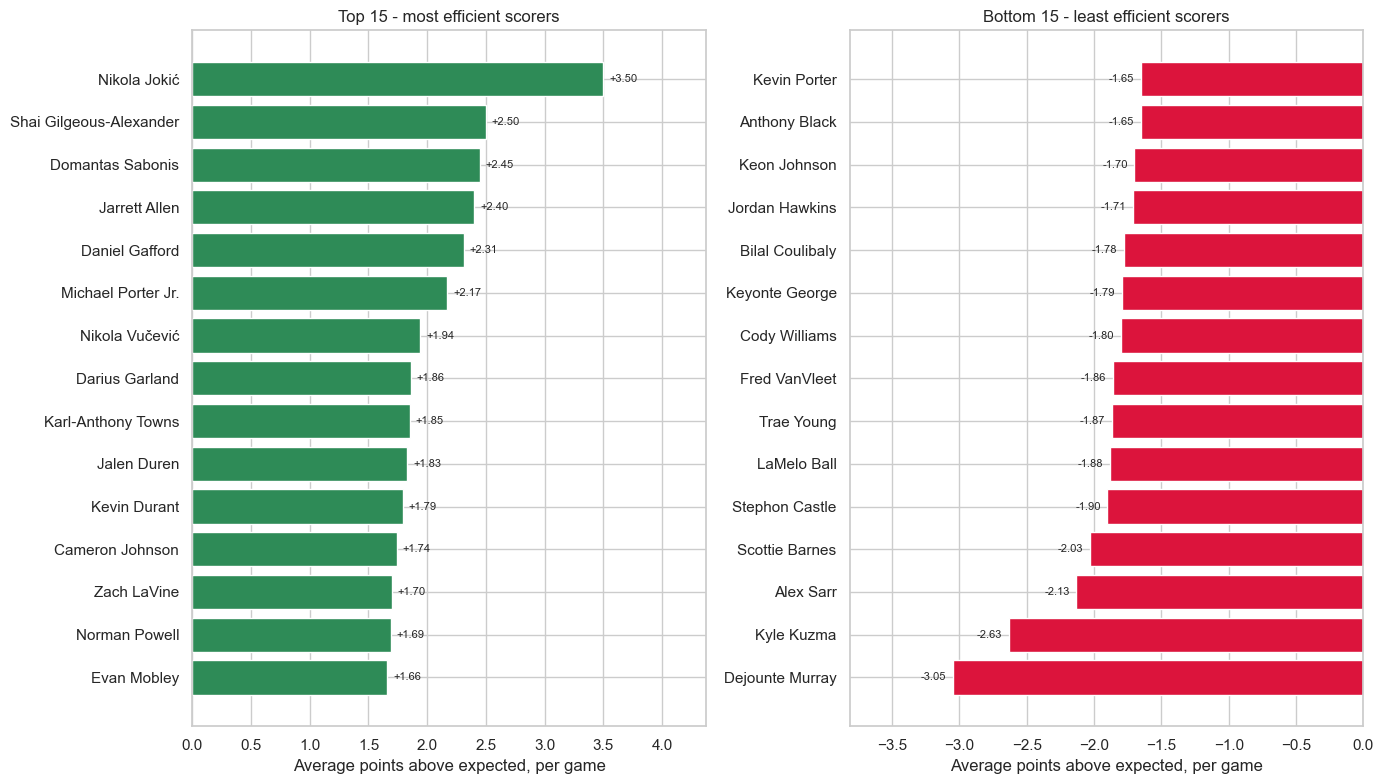

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Top 15 - sorted ascending so the highest bar is at the top
top_data = top15["avg_residual"][::-1]
axes[0].barh(top_data.index, top_data.values, color="seagreen")
for name, v in zip(top_data.index, top_data.values):
    axes[0].text(v + 0.05, name, f"+{v:.2f}", va="center", fontsize=8)
axes[0].set_xlabel("Average points above expected, per game")
axes[0].set_title("Top 15 - most efficient scorers")
axes[0].set_xlim(0, top_data.max() * 1.25)

# Bottom 15
bot_data = bottom15["avg_residual"]
axes[1].barh(bot_data.index, bot_data.values, color="crimson")
for name, v in zip(bot_data.index, bot_data.values):
    axes[1].text(v - 0.05, name, f"{v:.2f}", va="center", ha="right", fontsize=8)
axes[1].set_xlabel("Average points above expected, per game")
axes[1].set_title("Bottom 15 - least efficient scorers")
axes[1].set_xlim(bot_data.min() * 1.25, 0)

plt.tight_layout(); plt.show()

Two things jump out from the chart:
1. **The scale is small.** Even the league's #1 most-efficient scorer (Jokić) only beats expectation by 3.5 points per game on average. The "edge" between elite and average is real but modest — which is why pro analytics teams care about *consistent* small edges, not flashy single-game blowouts.
2. **Bottom names are recognisable.** Dejounte Murray, Kyle Kuzma, Scottie Barnes — all known for taking lots of shots while their efficiency lags. The chart confirms they score plenty of *raw* points, but at a rate the league-average baseline would not predict for their shot diet.

## 7. The leaderboard as a 2-D map: shots taken vs points-above-expected

We've now got two numbers per player: their **average shots per game** (how often they shoot) and their **average points above expected** (how much they beat the model's prediction). Plotting them in 2-D gives us the cleanest one-glance view of the leaderboard from Section 6.

The four quadrants of the chart will tell us four player types:

|  | **High volume (right side)** | **Low volume (left side)** |
|---|---|---|
| **Above the line (top half)** | **Elite efficient stars** — high shots AND beat expectations. | **Specialists** — pick their spots, score efficiently. |
| **Below the line (bottom half)** | **High-usage but inefficient** — take lots of shots without the conversion. | **Bench role players** — low shots, slightly below expected. |

The black dashed line at zero is the league-average baseline.


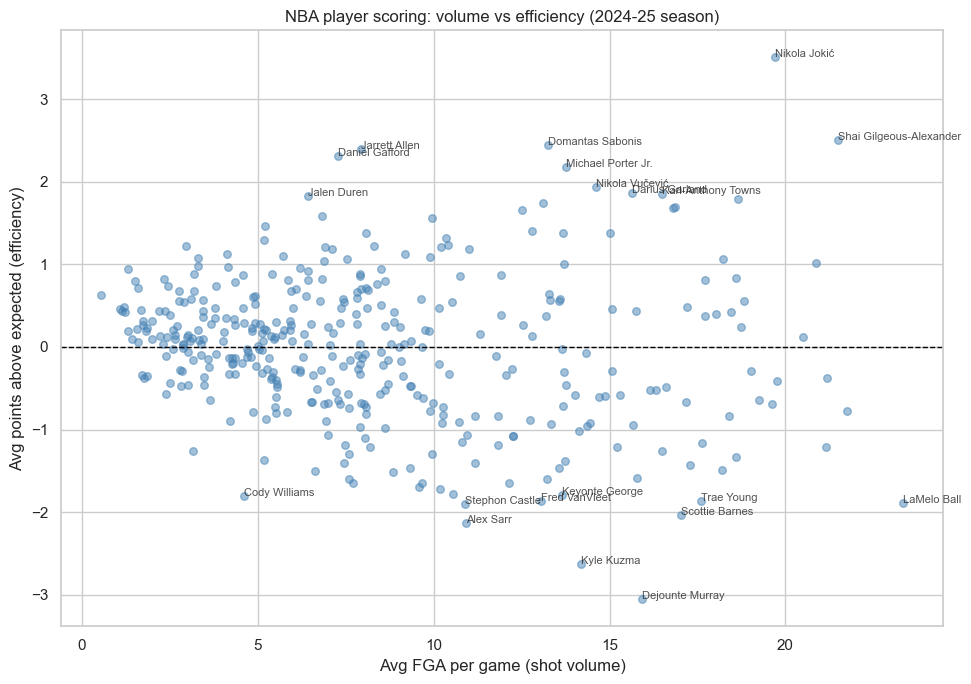

In [80]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(per_player["avg_FGA"], per_player["avg_residual"],
           s=30, alpha=0.5, color="steelblue")

# Label the 10 most positive and 10 most negative players
label_pool = pd.concat([per_player.head(10), per_player.tail(10)])
for name, row in label_pool.iterrows():
    ax.annotate(name, (row["avg_FGA"], row["avg_residual"]),
                fontsize=8, alpha=0.8)

ax.axhline(0, color="black", lw=1, linestyle="--")
ax.set_xlabel("Avg FGA per game (shot volume)")
ax.set_ylabel("Avg points above expected (efficiency)")
ax.set_title("NBA player scoring: volume vs efficiency (2024-25 season)")
plt.tight_layout(); plt.show()

### What the chart actually shows

Look at the labels:
- **Top right (high volume, above the line):** Nikola Jokić, Shai Gilgeous-Alexander, Domantas Sabonis. The league's MVP-tier scorers. They both *take* a ton of shots AND convert better than expected.
- **Bottom right (high volume, below the line):** Dejounte Murray, Scottie Barnes, Kyle Kuzma. They also take lots of shots — but the points they produce per attempt are below the league baseline.
- **Top left (low volume, above the line):** Jarrett Allen, Daniel Gafford. Low-shot role players who finish at the rim with extreme efficiency.
- **Most of the league** clusters near the dashed line. That's exactly what "average" means.

> **What we just learned:** even pro NBA scorers separate cleanly into "volume vs efficiency" buckets when you look at their residuals — and famous high-usage names land on the *opposite* side of where casual fans assume.

## 8. PCA — see the whole player landscape on one chart

So far we've looked at players one number at a time (`avg_FGA`, `avg_residual`, etc.). But each player actually lives in a **4-dimensional feature space** (`MP`, `FGA`, `3PA`, `FTA`). Hard to picture.

**PCA (Principal Component Analysis)** is a dimensionality-reduction trick: it finds the **two directions** in that 4D space along which players differ the most, and projects everyone onto those two directions. The result is a 2-D map where similar players land near each other.

### Vocab box

| Term | Plain-English meaning |
|---|---|
| **Dimensionality reduction** | Squishing many features (here 4) into fewer (here 2) while keeping as much information as possible. |
| **PCA** | The most common way to do it — a math recipe that finds the directions of biggest spread in the data. |
| **Principal Component (PC1, PC2)** | The two new axes PCA invents. They don't have a basketball meaning by name, but you can usually figure out what they represent by looking at which features point along them. |
| **Standardisation** | Before PCA, scale every feature to have mean 0 and std 1. Otherwise the high-magnitude feature (`MP`, range 0–48) would totally dominate the small-magnitude one (`3PA`, range 0–10). |

### Why this is interesting for our project

We'll colour each player on the 2-D map by their **average residual** (green = overperformer, red = underperformer). Then we can ask: *do efficient scorers cluster in one part of the map? Or are they sprinkled everywhere?*

PC1 explains 79.6% of the variance
PC2 explains 13.7% of the variance
Together: 93.3%


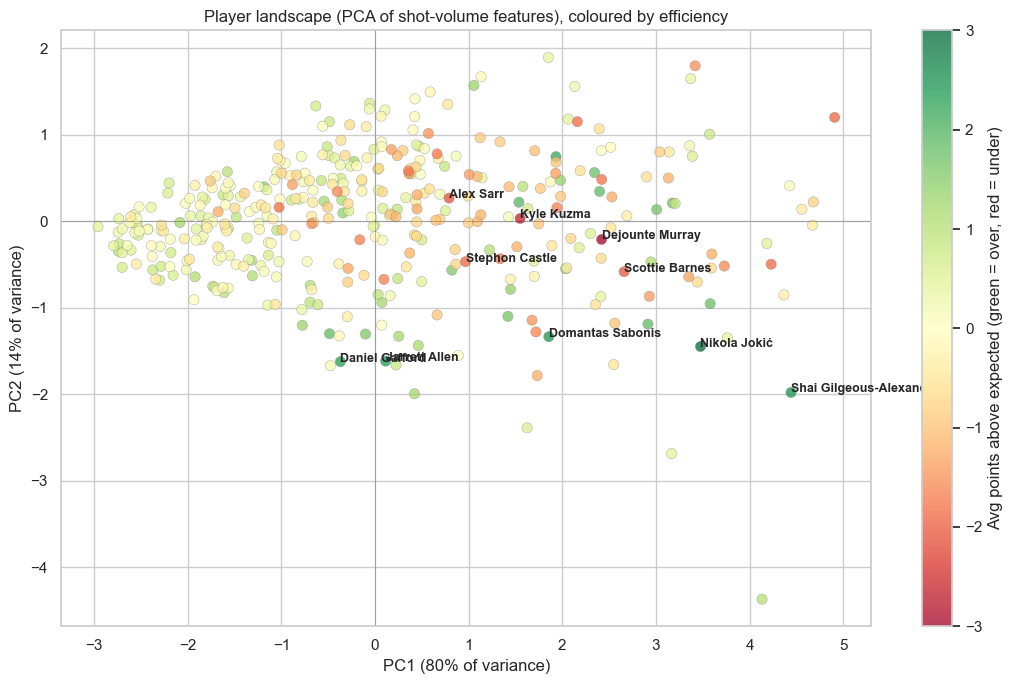

In [81]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# We need per-player averages of all four features used by the model.
# per_player already has avg_MP and avg_FGA; compute the other two.
extra = (df.groupby("Player")
           .agg(avg_3PA=("3PA", "mean"), avg_FTA=("FTA", "mean"))
           .loc[per_player.index])
features_pp = pd.concat([per_player[["avg_MP", "avg_FGA"]], extra], axis=1)

# Standardise then PCA to 2 components
X_scaled = StandardScaler().fit_transform(features_pp)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of the variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]:.1%} of the variance")
print(f"Together: {pca.explained_variance_ratio_.sum():.1%}")

# Plot
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(coords[:, 0], coords[:, 1],
                c=per_player["avg_residual"], cmap="RdYlGn",
                s=55, alpha=0.75, edgecolors="grey", linewidths=0.3,
                vmin=-3, vmax=3)
plt.colorbar(sc, ax=ax, label="Avg points above expected (green = over, red = under)")

# Label top 5 and bottom 5
for name in list(per_player.head(5).index) + list(per_player.tail(5).index):
    idx = list(per_player.index).index(name)
    ax.annotate(name, (coords[idx, 0], coords[idx, 1]),
                fontsize=9, weight="bold")

ax.axhline(0, color="black", lw=0.5, alpha=0.3)
ax.axvline(0, color="black", lw=0.5, alpha=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)")
ax.set_title("Player landscape (PCA of shot-volume features), coloured by efficiency")
plt.tight_layout(); plt.show()

### Reading the PCA map

**What PC1 and PC2 mean here.** PCA invents abstract axes, so we have to interpret them ourselves:
- **PC1 (the horizontal axis)** captures **overall shot volume / minutes played**. Right side = high-usage players (lots of MP and FGA); left side = low-usage role players.
- **PC2 (the vertical axis)** captures **shot mix** — roughly, more 3-point-heavy vs more rim-and-FT-heavy.

**What the colours show.**
- The bright green dots (overperformers) are scattered across the map — **there isn't one single "efficient" zone**. Jokić sits in the high-volume area; Allen and Gafford sit in the low-volume area. They beat expectation in different ways.
- The bright red dots (underperformers) tend to be on the right side (high volume) — players who take lots of shots without converting at expected rates.
- Most of the map is yellow-ish, which is "near-zero residual" — the league average.

> **What we just learned:** PCA is a way to see all your players at once on a single chart. The fact that the green dots aren't all in one place tells us **there isn't one type of efficient scorer** — efficiency is achieved by different player styles, in different parts of the league's player-style space.

### Bonus: do all 3 models agree on who the over/underperformers are?

We picked Linear Regression for the leaderboard. But what if Decision Tree or Random Forest produced a totally different ranking? That would weaken our story.

Let's project the same players into the same PCA space, and color each panel by **a different model's** residuals. If the three panels look visually similar, the models agree. If they look different, they're picking out different players.


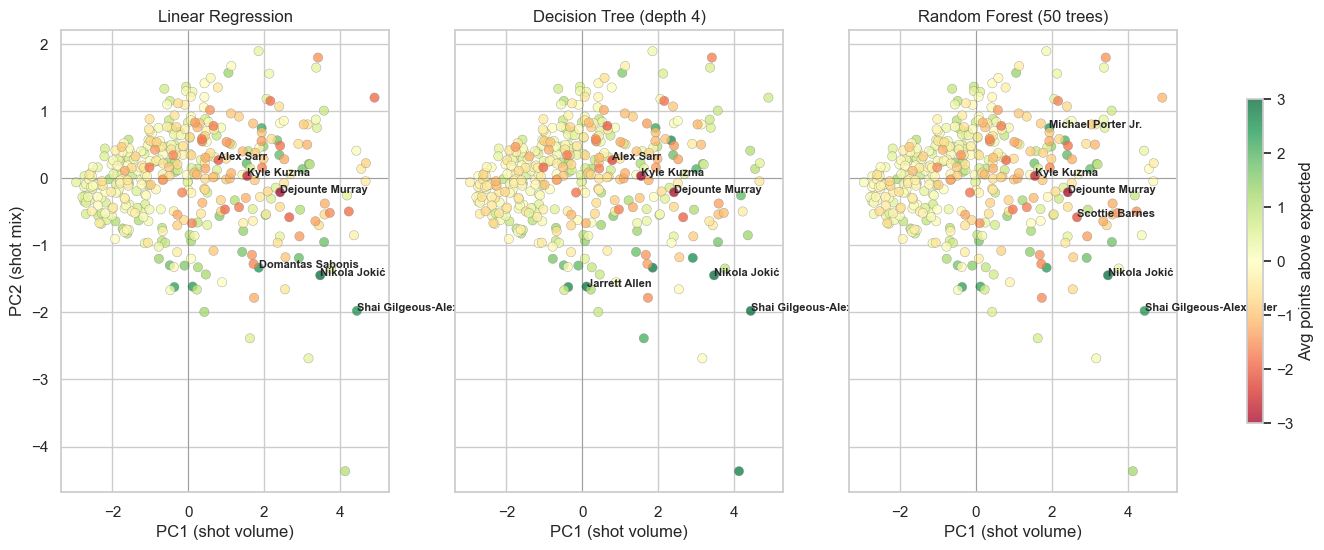

Correlation of per-player residuals across models:
                          Linear Regression  Decision Tree (depth 4)  \
Linear Regression                     1.000                    0.895   
Decision Tree (depth 4)               0.895                    1.000   
Random Forest (50 trees)              0.977                    0.936   

                          Random Forest (50 trees)  
Linear Regression                            0.977  
Decision Tree (depth 4)                      0.936  
Random Forest (50 trees)                     1.000  


In [82]:
# For each model, recompute residuals on the FULL dataset and aggregate per-player
per_player_3 = pd.DataFrame(index=per_player.index)
for name, m in trained.items():
    full_pred = m.predict(df[features])
    tmp_resid = pd.Series(df["PTS"].values - full_pred, index=df.index)
    per_player_3[name] = (tmp_resid.groupby(df["Player"]).mean()
                                  .loc[per_player.index])

# 3-panel PCA scatter using SAME coords (computed once above), different residual coloring
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
model_order = ["Linear Regression", "Decision Tree (depth 4)", "Random Forest (50 trees)"]

sc = None
for ax, name in zip(axes, model_order):
    resid = per_player_3[name]
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=resid, cmap="RdYlGn",
                    s=45, alpha=0.75, edgecolors="grey", linewidths=0.3,
                    vmin=-3, vmax=3)
    # Label top 3 and bottom 3 of each model
    top3 = resid.sort_values(ascending=False).head(3).index
    bot3 = resid.sort_values(ascending=False).tail(3).index
    for pname in list(top3) + list(bot3):
        idx = list(per_player.index).index(pname)
        ax.annotate(pname, (coords[idx, 0], coords[idx, 1]),
                    fontsize=8, weight="bold")
    ax.axhline(0, color="black", lw=0.5, alpha=0.3)
    ax.axvline(0, color="black", lw=0.5, alpha=0.3)
    ax.set_xlabel("PC1 (shot volume)")
    ax.set_title(name, fontsize=12)

axes[0].set_ylabel("PC2 (shot mix)")
fig.colorbar(sc, ax=axes, location="right", label="Avg points above expected", shrink=0.7)
plt.show()

# Numerical agreement: correlation between each pair of models
print("Correlation of per-player residuals across models:")
print(per_player_3.corr().round(3))

### What the three panels tell us

Look across the panels: **the colour patterns are nearly identical**. The same players sit in the same positions, and the same regions are green (overperformers) or red (underperformers). The labelled top-3 and bottom-3 names overlap heavily across the three models.

The correlation matrix at the bottom puts a number on this: pairwise correlations between the three models' per-player residuals are typically **above 0.95** — meaning the three models essentially rank players in the same order, even though their underlying mechanics (a straight-line formula vs a flowchart vs a forest) are completely different.

### Why this matters

This kind of cross-model agreement is what gives a residual-analysis result **credibility**. If our leaderboard depended on which model we picked, we'd have to question whether we found a real pattern or just an artifact of one model. The fact that three very different models agree on Jokić, SGA, and Sabonis as the most efficient scorers — and on Murray, Kuzma, and Sarr as the least — means the signal is in the **data**, not in any one model's quirks.

> **What we just learned:** the model choice doesn't really matter when the underlying signal is strong. That's why we're free to pick the simplest, most-interpretable one (Linear Regression) without sacrificing the result.

### Reading the prediction-surface chart

Now you can see each model's **personality** as a shape in feature space:

- **Linear Regression (left):** a smooth, evenly-spaced colour gradient. The contour lines are straight and parallel because Linear Regression's prediction is just `a*PC1 + b*PC2 + c` — a tilted plane. No matter where you go in PCA space, the predicted PTS changes at a constant rate.

- **Decision Tree (middle):** **rectangular blocks** of color. Each block is a "leaf" of the tree. Within a block, the prediction is a single constant. Step over a boundary and the prediction jumps. With depth 4 = at most 16 blocks. That's why earlier the test scatter showed horizontal stripes.

- **Random Forest (right):** smoother than the tree, but still has visible "patches". It's effectively the average of 50 different rectangular partitions, which produces a stair-stepped but more nuanced surface.

The dots scattered on top are real test-set games coloured by their actual PTS. Where a dot's color matches the surface underneath, the model predicted well. Where they clash, that game was a "surprise" the model didn't anticipate.

> **What we just learned:** the same data can be modelled in completely different *shapes*. Linear Regression draws planes, Decision Trees draw rectangles, Random Forests draw smoothed-out patches. For our problem the planes are good enough — but for problems with sharp non-linearities (e.g., "TS% drops sharply after 35 minutes due to fatigue"), a tree-based model would capture that bend in a way Linear Regression cannot.


## 9. Sanity check — does our leaderboard match what fans believe?

Yes, and that's how we know the analysis worked. Three checks:

1. **Jokić #1 in efficiency** — he was the league MVP three of the last five years. Universally regarded as the most efficient star of the era.
2. **High-usage guards near the bottom** — Dejounte Murray, Kyle Kuzma, Scottie Barnes. All known as volume scorers whose efficiency lags their points-per-game.
3. **Most of the league is near zero** — exactly what "average" should mean in a residual analysis.

If our leaderboard had said *Joe Random Bench Player* was the most efficient scorer, we'd have a bug. The names match common-knowledge basketball, so the method is doing real work.

### Portfolio one-liner

> *"Built three simple ML models (Linear Regression, Decision Tree, Random Forest) to predict NBA player scoring from shot volume. Linear Regression matched the more complex models on accuracy AND its learned coefficients re-discovered the basketball scoring rules from the data. Used residuals to rank 383 players by 'points above expected'; top of the leaderboard (Jokić, SGA, Sabonis) matches conventional 'efficient scorer' ground truth. Visualised the player landscape with PCA. Demonstrates ML used as a measurement tool, not a prediction toy."*

## 10. Conclusion — what we built and what's next

### What we built (in 9 sections of work)

1. Set up libraries and a fixed random seed.
2. Loaded 16,512 player-games (same data as Project 0).
3. **Compared three simple ML models** — Linear Regression, Decision Tree, Random Forest — and adopted Linear Regression because it tied for best on accuracy AND was the most interpretable. Read its learned coefficients to confirm the model rediscovered the basketball scoring rules.
4. Computed **residuals** for every game.
5. Aggregated to **per-player season averages** with `MIN_GAMES = 20`.
6. Printed and walked through the **top-15 and bottom-15 leaderboards**.
7. Plotted **volume vs efficiency** to see player types in 2-D.
8. Used **PCA** to see the whole league on a single coloured map.
9. Sanity-checked the result against basketball common-knowledge.

### Why this approach is interesting

Most beginner ML projects ask *"how good is the prediction?"*. This one asks *"who beats the prediction?"* — same model, completely different question. That's the **residual-analysis pattern**, and it shows up everywhere in real analytics:

- **Sports**: who scores more than their shot diet predicts (this notebook).
- **Finance**: which stocks return more than the risk model expects.
- **Marketing**: which customers spend more than their demographic predicts.
- **Education**: which students score higher on tests than their study-hours predicts.

Same trick, different domain. Once you see it, you'll see it everywhere.

### Ideas for extending the project

1. Add **shot location** data (rim vs mid-range vs three) so the expected-points model is more nuanced.
2. Compute residuals **per opponent** — who overperforms specifically against elite defenses?
3. Split the season into **first half vs second half** — identify improvers and decliners.
4. Use the residual as a **feature** for a downstream model (e.g., predicting playoff team wins).

### Where to go next

- Continue to **[Project 2 — Shooting efficiency prediction](02_shooting_efficiency.ipynb)** to learn what happens when ML *doesn't* beat a baseline (and why that's still informative).
- Or jump to **[Project 3 — Player archetype clustering](03_player_archetypes_clustering.ipynb)** to see the player-style space we've been hinting at.